# Olist Large Datase

In [1]:
import numpy as np  # linear algebra
import pandas as pd  # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the "../Source data/OListDatasets/" directory
import os
for dirname, _, filenames in os.walk('../Source data/OListDatasets/'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


../Source data/OListDatasets/olist_customers_dataset.csv
../Source data/OListDatasets/olist_geolocation_dataset.csv
../Source data/OListDatasets/olist_orders_dataset.csv
../Source data/OListDatasets/olist_order_items_dataset.csv
../Source data/OListDatasets/olist_order_payments_dataset.csv
../Source data/OListDatasets/olist_order_reviews_dataset.csv
../Source data/OListDatasets/olist_products_dataset.csv
../Source data/OListDatasets/olist_sellers_dataset.csv
../Source data/OListDatasets/product_category_name_translation.csv


# *Outline of Project Structure:*

1. *Data Modelling*
2. *Data Profiling*
3. *Data Cleaning*
4. *Data Analytics*
5. *Interpretation of Results*



## Data Modelling 

In [2]:
"""customers
├── customer_id
├── customer_unique_id
├── customer_city
└── customer_state
        ↓ (customer_id)

orders
├── order_id
├── customer_id (FK)
├── order_status
├── order_purchase_timestamp
└── order_delivered_customer_date
        ↓ (order_id)

order_items
├── order_id (FK)
├── product_id
├── seller_id
├── price
└── freight_value
        ↓              ↓

products         sellers
├── product_id    ├── seller_id
├── product_category_name
└── product_weight_g
        ↓
product_category_name_translation
└── product_category_name_english

orders
  ↓
order_payments
├── order_id (FK)
├── payment_type
└── payment_value

orders
  ↓
order_reviews
├── order_id (FK)
├── review_score
└── review_comment_message"""


'customers\n├── customer_id\n├── customer_unique_id\n├── customer_city\n└── customer_state\n        ↓ (customer_id)\n\norders\n├── order_id\n├── customer_id (FK)\n├── order_status\n├── order_purchase_timestamp\n└── order_delivered_customer_date\n        ↓ (order_id)\n\norder_items\n├── order_id (FK)\n├── product_id\n├── seller_id\n├── price\n└── freight_value\n        ↓              ↓\n\nproducts         sellers\n├── product_id    ├── seller_id\n├── product_category_name\n└── product_weight_g\n        ↓\nproduct_category_name_translation\n└── product_category_name_english\n\norders\n  ↓\norder_payments\n├── order_id (FK)\n├── payment_type\n└── payment_value\n\norders\n  ↓\norder_reviews\n├── order_id (FK)\n├── review_score\n└── review_comment_message'

## Data Profiling

In [3]:
import pandas as pd
import os
import glob

# Path to your Olist dataset folder
path = "../Source data/OListDatasets/"

# Grab all CSV files in that folder
csv_files = glob.glob(os.path.join(path, "*.csv"))

datasets = {}

# Load each CSV into a DataFrame
for file in csv_files:
    name = os.path.basename(file).replace(".csv", "")
    datasets[name] = pd.read_csv(file)
    print(f"\n📂 Loaded {name}: {datasets[name].shape[0]} rows × {datasets[name].shape[1]} columns")
    
    # Show info
    print("\n--- INFO ---")
    print(datasets[name].info())
    
    # Show describe
    print("\n--- DESCRIBE ---")
    print(datasets[name].describe(include='all'))  # include='all' shows categorical + numeric
    print("\n" + "="*80 + "\n")


📂 Loaded olist_customers_dataset: 99441 rows × 5 columns

--- INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB
None

--- DESCRIBE ---
                             customer_id                customer_unique_id  \
count                              99441                             99441   
unique                             99441                             96096   
top     06b8999e2fba1a1fbc88172c00ba8bc7  8d50f5eadf50201ccdcedfb9e2ac8455   
freq                                   1                 

In [4]:
import pandas as pd
import os

data_path = "../Source data/OListDatasets/"

df_dict = {}

for filename in os.listdir(data_path):
    if filename.endswith(".csv"):
        df_name = filename.replace(".csv"," ")
        df_dict[df_name]= pd.read_csv(os.path.join(data_path, filename))

for name, df in df_dict.items():
    print(f"{name}: {df.shape}")


    
    

olist_customers_dataset : (99441, 5)
olist_geolocation_dataset : (1000163, 5)
olist_orders_dataset : (99441, 8)
olist_order_items_dataset : (112650, 7)
olist_order_payments_dataset : (103886, 5)
olist_order_reviews_dataset : (99224, 7)
olist_products_dataset : (32951, 9)
olist_sellers_dataset : (3095, 4)
product_category_name_translation : (71, 2)


In [5]:
df_dict.keys()

dict_keys(['olist_customers_dataset ', 'olist_geolocation_dataset ', 'olist_orders_dataset ', 'olist_order_items_dataset ', 'olist_order_payments_dataset ', 'olist_order_reviews_dataset ', 'olist_products_dataset ', 'olist_sellers_dataset ', 'product_category_name_translation '])

In [6]:
for name, df in df_dict.items():
    print(f"\n {name}")
    print(df.dtypes)


 olist_customers_dataset 
customer_id                 object
customer_unique_id          object
customer_zip_code_prefix     int64
customer_city               object
customer_state              object
dtype: object

 olist_geolocation_dataset 
geolocation_zip_code_prefix      int64
geolocation_lat                float64
geolocation_lng                float64
geolocation_city                object
geolocation_state               object
dtype: object

 olist_orders_dataset 
order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

 olist_order_items_dataset 
order_id                object
order_item_id            int64
product_id              object
seller_id               object
shipping_limit_date     object
pric

### Fix Date time in all tables


In [7]:
# Explicit list of known datetime columns across all tables
datetime_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
    'review_creation_date',
    'review_answer_timestamp',
    'shipping_limit_date'
]

# Convert them if they exist in each DataFrame
for name, df in df_dict.items():
    for col in datetime_columns:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors='coerce')
            print(f" Converted {col} in {name}")


 Converted order_purchase_timestamp in olist_orders_dataset 
 Converted order_approved_at in olist_orders_dataset 
 Converted order_delivered_carrier_date in olist_orders_dataset 
 Converted order_delivered_customer_date in olist_orders_dataset 
 Converted order_estimated_delivery_date in olist_orders_dataset 
 Converted shipping_limit_date in olist_order_items_dataset 
 Converted review_creation_date in olist_order_reviews_dataset 
 Converted review_answer_timestamp in olist_order_reviews_dataset 


In [8]:
import warnings
warnings.filterwarnings('ignore')

In [9]:
import numpy as np

for name, df in df_dict.items():
    print(f"\n {name}")
    print("-" * 60)
    
    # 1. Numerical columns
    num_cols = df.select_dtypes(include=np.number)
    if not num_cols.empty:
        print("\n Numeric Columns Summary:")
        print(num_cols.describe())

    # 2. Categorical columns
    cat_cols = df.select_dtypes(include=['object', 'category'])
    if not cat_cols.empty:
        print("\n Categorical Columns Summary:")
        print(cat_cols.describe())

    # 3. Datetime columns
    dt_cols = df.select_dtypes(include='datetime')
    if not dt_cols.empty:
        print("\n Datetime Columns Range:")
        for col in dt_cols.columns:
            print(f"  {col}: min = {df[col].min()}, max = {df[col].max()}")



 olist_customers_dataset 
------------------------------------------------------------

 Numeric Columns Summary:
       customer_zip_code_prefix
count              99441.000000
mean               35137.474583
std                29797.938996
min                 1003.000000
25%                11347.000000
50%                24416.000000
75%                58900.000000
max                99990.000000

 Categorical Columns Summary:
                             customer_id                customer_unique_id  \
count                              99441                             99441   
unique                             99441                             96096   
top     06b8999e2fba1a1fbc88172c00ba8bc7  8d50f5eadf50201ccdcedfb9e2ac8455   
freq                                   1                                17   

       customer_city customer_state  
count          99441          99441  
unique          4119             27  
top        sao paulo             SP  
freq           15540   

**Missing Values Check!**


In [10]:
for name, df in df_dict.items():
    missing = df.isnull().sum()
    missing = missing[missing > 0].sort_values(ascending=False)

    if not missing.empty:
        print(f"\n {name}")
        print("-" * 60)
        print(" Columns with Missing Values:")
        print(missing)
    



 olist_orders_dataset 
------------------------------------------------------------
 Columns with Missing Values:
order_delivered_customer_date    2965
order_delivered_carrier_date     1783
order_approved_at                 160
dtype: int64

 olist_order_reviews_dataset 
------------------------------------------------------------
 Columns with Missing Values:
review_comment_title      87656
review_comment_message    58247
dtype: int64

 olist_products_dataset 
------------------------------------------------------------
 Columns with Missing Values:
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64


**Inspecting Negative Numeric Columns!**  and **Check Past or Future Dates which can be invalid**


In [11]:
import datetime

today = pd.Timestamp(datetime.datetime.today().date())

for name, df in df_dict.items():
    output = []

    # Check for negative values in numeric columns
    num_cols = df.select_dtypes(include=np.number)
    for col in num_cols.columns:
        neg_count = (df[col] < 0).sum()
        if neg_count > 0:
            output.append(f"{col} has {neg_count} negative values.")

    # Check for dates before 1970
    dt_cols = df.select_dtypes(include='datetime')
    for col in dt_cols.columns:
        old_date_count = (df[col] < pd.Timestamp("1970-01-01")).sum()
        if old_date_count > 0:
            output.append(f"{col} has {old_date_count} dates before 1970-01-01.")

    # Check for future dates
    for col in dt_cols.columns:
        future_count = (df[col] > today).sum()
        if future_count > 0:
            output.append(f"{col} has {future_count} dates in the future.")

    # Print only if any issues found
    if output:
        print(f"\n{name}")
        print("-" * 60)
        for line in output:
            print(line)



olist_geolocation_dataset 
------------------------------------------------------------
geolocation_lat has 998827 negative values.
geolocation_lng has 1000160 negative values.


**Duplicates Check!**


In [12]:
for name, df in df_dict.items():
    if df.duplicated().sum() > 0:
        print(f"{name} has {df.duplicated().sum()} duplicate rows.")


olist_geolocation_dataset  has 261831 duplicate rows.


**Zero Variance Check!**


In [13]:
for name, df in df_dict.items():
    constant_cols = [col for col in df.columns if df[col].nunique() <= 1]
    if constant_cols:
        print(f"{name} has constant columns: {constant_cols}")


**Cardinality Checks!** Setting threshold to >50


In [14]:
for name, df in df_dict.items():
    cat_cols = df.select_dtypes(include=['object', 'category'])
    for col in cat_cols.columns:
        uniq = df[col].nunique()
        if uniq > 50:
            print(f"{name} → {col} has high cardinality: {uniq} unique values")


olist_customers_dataset  → customer_id has high cardinality: 99441 unique values
olist_customers_dataset  → customer_unique_id has high cardinality: 96096 unique values
olist_customers_dataset  → customer_city has high cardinality: 4119 unique values
olist_geolocation_dataset  → geolocation_city has high cardinality: 8011 unique values
olist_orders_dataset  → order_id has high cardinality: 99441 unique values
olist_orders_dataset  → customer_id has high cardinality: 99441 unique values
olist_order_items_dataset  → order_id has high cardinality: 98666 unique values
olist_order_items_dataset  → product_id has high cardinality: 32951 unique values
olist_order_items_dataset  → seller_id has high cardinality: 3095 unique values
olist_order_payments_dataset  → order_id has high cardinality: 99440 unique values
olist_order_reviews_dataset  → review_id has high cardinality: 98410 unique values
olist_order_reviews_dataset  → order_id has high cardinality: 98673 unique values
olist_order_reviews

**Count of Unique datas in Categorical columns**


In [15]:
for name, df in df_dict.items():
    # Get all object/category columns
    cat_cols = df.select_dtypes(include=['object', 'category']).columns
    
    # Exclude columns ending with '_id'
    filtered_cols = [col for col in cat_cols if not col.endswith('_id')]
    
    if filtered_cols:
        print(f"\n{name}")
        print("-" * 60)
        for col in filtered_cols:
            print(f"{col}: {df[col].nunique()} unique categories")



olist_customers_dataset 
------------------------------------------------------------
customer_city: 4119 unique categories
customer_state: 27 unique categories

olist_geolocation_dataset 
------------------------------------------------------------
geolocation_city: 8011 unique categories
geolocation_state: 27 unique categories

olist_orders_dataset 
------------------------------------------------------------
order_status: 8 unique categories

olist_order_payments_dataset 
------------------------------------------------------------
payment_type: 5 unique categories

olist_order_reviews_dataset 
------------------------------------------------------------
review_comment_title: 4527 unique categories
review_comment_message: 36159 unique categories

olist_products_dataset 
------------------------------------------------------------
product_category_name: 73 unique categories

olist_sellers_dataset 
------------------------------------------------------------
seller_city: 611 unique c

**Inconsistent Text entries in Categorical columns check**


In [16]:
for name, df in df_dict.items():
    cat_cols = df.select_dtypes(include=['object', 'category']).columns
    # Exclude technical IDs
    filtered = [col for col in cat_cols if not col.endswith('_id')]
    
    for col in filtered:
        values = df[col].dropna().unique()
        # Look for suspicious duplicates by normalizing case/space
        cleaned = pd.Series(values).str.strip().str.lower()
        if cleaned.nunique() < len(values):  # Suggests duplicates in disguise
            print(f"{name} → {col}: {len(values)} values, {cleaned.nunique()} normalized → needs cleaning")


olist_geolocation_dataset  → geolocation_city: 8011 values, 8010 normalized → needs cleaning
olist_order_reviews_dataset  → review_comment_title: 4527 values, 3679 normalized → needs cleaning
olist_order_reviews_dataset  → review_comment_message: 36159 values, 35007 normalized → needs cleaning


In [17]:
for name, df in df_dict.items():
    cat_cols = df.select_dtypes(include=['object', 'category']).columns
    filtered = [col for col in cat_cols if not col.endswith('_id')]

    for col in filtered:
        # Apply normalization: strip spaces, make lowercase or title case
        df[col] = df[col].astype(str).str.strip().str.lower()


In [18]:
for name, df in df_dict.items():
    for col in df.select_dtypes(include='object').columns:
        if not col.endswith('_id'):
            print(f"{name} → {col}: {df[col].nunique()} unique after cleaning")


olist_customers_dataset  → customer_city: 4119 unique after cleaning
olist_customers_dataset  → customer_state: 27 unique after cleaning
olist_geolocation_dataset  → geolocation_city: 8010 unique after cleaning
olist_geolocation_dataset  → geolocation_state: 27 unique after cleaning
olist_orders_dataset  → order_status: 8 unique after cleaning
olist_order_payments_dataset  → payment_type: 5 unique after cleaning
olist_order_reviews_dataset  → review_comment_title: 3680 unique after cleaning
olist_order_reviews_dataset  → review_comment_message: 35008 unique after cleaning
olist_products_dataset  → product_category_name: 74 unique after cleaning
olist_sellers_dataset  → seller_city: 611 unique after cleaning
olist_sellers_dataset  → seller_state: 23 unique after cleaning
product_category_name_translation  → product_category_name: 71 unique after cleaning
product_category_name_translation  → product_category_name_english: 71 unique after cleaning


**Cleaned Dataframe Summary**


In [19]:
for name, df in df_dict.items():
    print(f"\n{name}")
    print("-" * 60)
    
    # Numeric summary
    num_cols = df.select_dtypes(include=['number']).columns
    if len(num_cols) > 0:
        print("\n Numeric Columns:")
        print(df[num_cols].describe())

    # Categorical summary
    cat_cols = df.select_dtypes(include=['object', 'category']).columns
    if len(cat_cols) > 0:
        print("\n Categorical Columns:")
        print(df[cat_cols].describe(include='all'))

    # Datetime summary
    dt_cols = df.select_dtypes(include='datetime').columns
    if len(dt_cols) > 0:
        print("\n Datetime Columns:")
        for col in dt_cols:
            print(f"{col}: min = {df[col].min()}, max = {df[col].max()}")



olist_customers_dataset 
------------------------------------------------------------

 Numeric Columns:
       customer_zip_code_prefix
count              99441.000000
mean               35137.474583
std                29797.938996
min                 1003.000000
25%                11347.000000
50%                24416.000000
75%                58900.000000
max                99990.000000

 Categorical Columns:
                             customer_id                customer_unique_id  \
count                              99441                             99441   
unique                             99441                             96096   
top     06b8999e2fba1a1fbc88172c00ba8bc7  8d50f5eadf50201ccdcedfb9e2ac8455   
freq                                   1                                17   

       customer_city customer_state  
count          99441          99441  
unique          4119             27  
top        sao paulo             sp  
freq           15540          41746  

o

 ------------------------------------------**Sales and Revenue Analysis**--------------------------------------------------------------


In [20]:
df = df_dict['olist_order_items_dataset ']
print(df.columns.tolist())
df_dict = {k.strip(): v for k, v in df_dict.items()}
df = df_dict['olist_order_items_dataset']
print(df.columns.tolist())


['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']


In [21]:
#Total Revenue

#Revenue excluding Freight value = Product Revenue
Total_revenue = df['price'].sum()
print(Total_revenue, "Brazilian Real")

#Revenue inclding freight value = Total Gross revenue from customer
cust_revenue = df['price'].sum() + df['freight_value'].sum()
print(cust_revenue,"Brazilian Real")

13591643.7 Brazilian Real
15843553.239999998 Brazilian Real


In [22]:
!pip install duckdb --quiet
import duckdb


print(df_dict.keys())

orders = df_dict['olist_orders_dataset']
items = df_dict['olist_order_items_dataset']

#Using SQL to merge columns

result = duckdb.query("""
    SELECT 
        o.order_id,
        o.order_purchase_timestamp,
        i.price,
        i.freight_value
    FROM orders o
    JOIN items i
    ON o.order_id = i.order_id
""").to_df()
    


dict_keys(['olist_customers_dataset', 'olist_geolocation_dataset', 'olist_orders_dataset', 'olist_order_items_dataset', 'olist_order_payments_dataset', 'olist_order_reviews_dataset', 'olist_products_dataset', 'olist_sellers_dataset', 'product_category_name_translation'])


In [23]:
#Calculate Monthly Revenue


result['order_year'] = result['order_purchase_timestamp'].dt.year
result['order_month_name'] = result['order_purchase_timestamp'].dt.strftime('%B')
result['order_month_num'] = result['order_purchase_timestamp'].dt.month

monthly_grouped = result.groupby(
    ['order_year', 'order_month_num', 'order_month_name'],
    sort=True
).agg(
    price_sum=('price', 'sum'),
    freight_sum=('freight_value', 'sum')
).reset_index()

# Add total revenue column
monthly_grouped['total_revenue'] = monthly_grouped['price_sum'] + monthly_grouped['freight_sum']
monthly_grouped = monthly_grouped.sort_values(['order_year', 'order_month_num'])


In [24]:
monthly_grouped['month_year'] = monthly_grouped['order_month_name'] + " " + monthly_grouped['order_year'].astype(str)


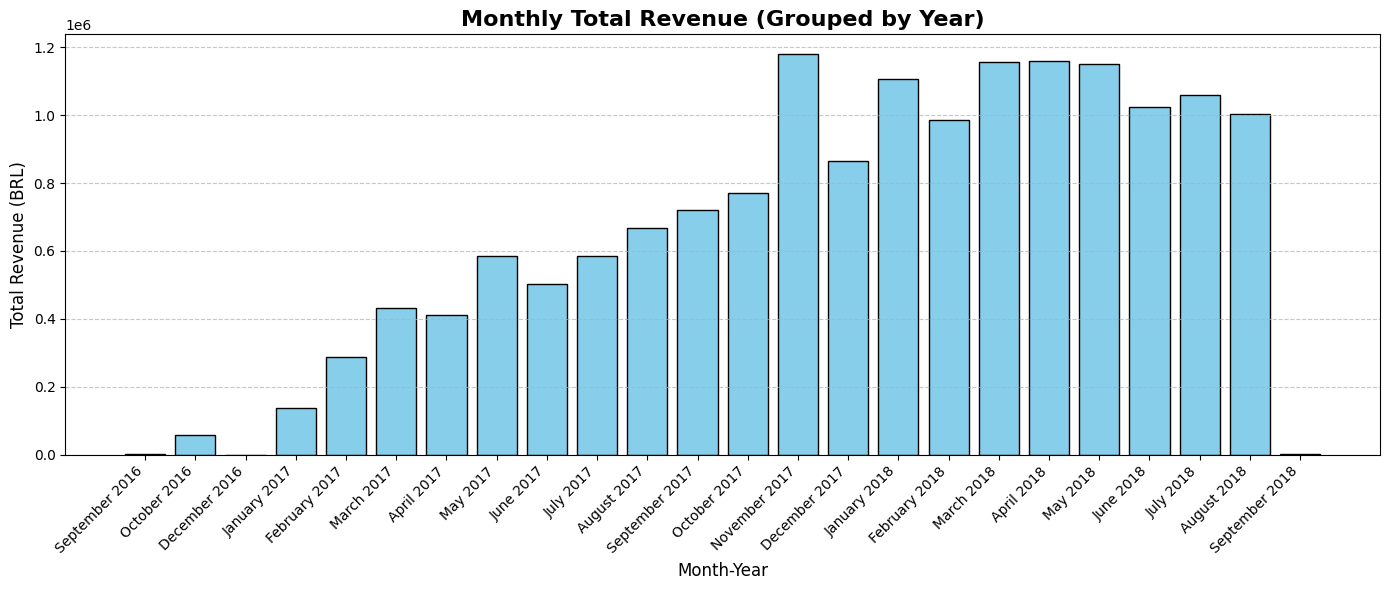

In [25]:
import matplotlib.pyplot as plt

# Ensure month_year is string for plotting
monthly_grouped['month_year'] = monthly_grouped['month_year'].astype(str)

# Set figure size
plt.figure(figsize=(14, 6))

# Create bar chart
plt.bar(
    monthly_grouped['month_year'],
    monthly_grouped['total_revenue'],
    color='skyblue',
    edgecolor='black'
)

# Add titles and labels
plt.title('Monthly Total Revenue (Grouped by Year)', fontsize=16, fontweight='bold')
plt.xlabel('Month-Year', fontsize=12)
plt.ylabel('Total Revenue (BRL)', fontsize=12)

# Rotate x-axis labels for readability
plt.xticks(rotation=45, ha='right')

# Add gridlines for clarity
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Tight layout for better spacing
plt.tight_layout()

# Show the chart
plt.show()

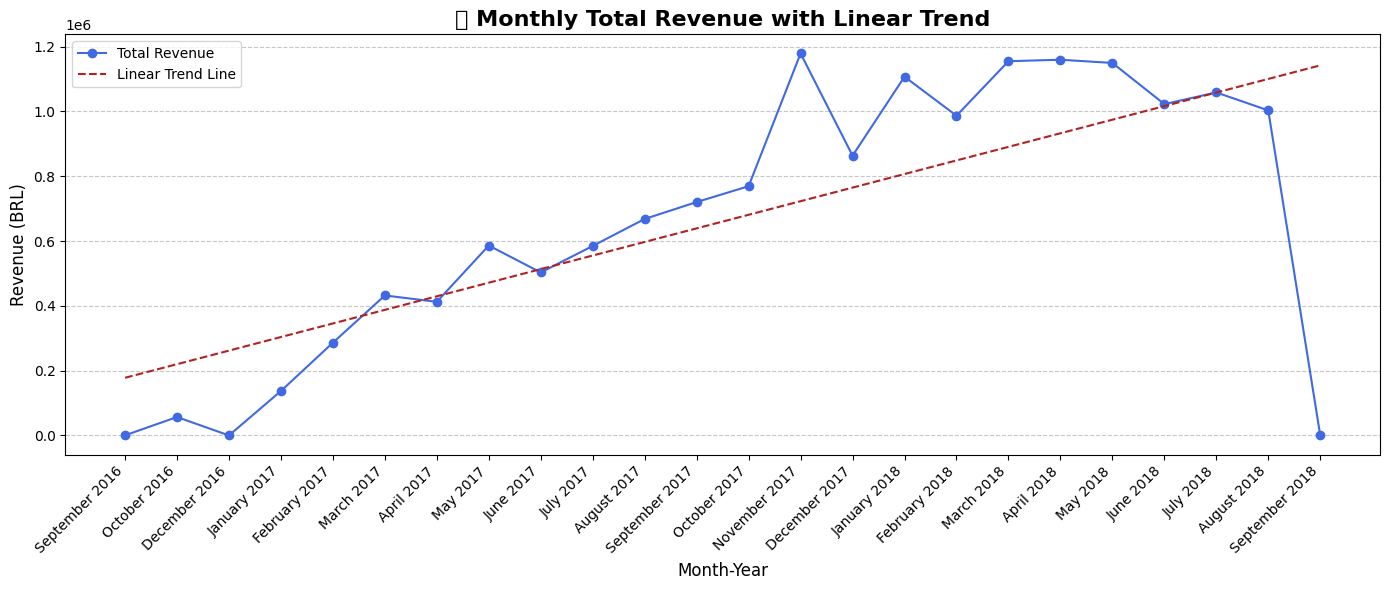

In [26]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress

# Ensure month_year is string for plotting
monthly_grouped['month_year'] = monthly_grouped['month_year'].astype(str)

# Prepare regression data
x = np.arange(len(monthly_grouped))
y = monthly_grouped['total_revenue'].values

slope, intercept, *_ = linregress(x, y)
trend = slope * x + intercept

# --- Plot with Matplotlib ---
plt.figure(figsize=(14, 6))

# Plot total revenue line
plt.plot(monthly_grouped['month_year'], y,
         marker='o', color='royalblue', label='Total Revenue')

# Plot linear trend line
plt.plot(monthly_grouped['month_year'], trend,
         color='firebrick', linestyle='--', label='Linear Trend Line')

# Add titles and labels
plt.title('📈 Monthly Total Revenue with Linear Trend', fontsize=16, fontweight='bold')
plt.xlabel('Month-Year', fontsize=12)
plt.ylabel('Revenue (BRL)', fontsize=12)

# Rotate x-axis labels for readability
plt.xticks(rotation=45, ha='right')

# Add gridlines
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add legend
plt.legend()

# Tight layout for spacing
plt.tight_layout()

# Show chart inline in notebook
plt.show()

### Register both frame


In [27]:
import matplotlib.pyplot as plt

# Ensure month is string for plotting
monthly_arpu['month'] = monthly_arpu['month'].astype(str)

# --- Plot with Matplotlib ---
plt.figure(figsize=(14, 6))

# Plot ARPU line
plt.plot(monthly_arpu['month'], monthly_arpu['ARPU'],
         marker='o', color='teal', linewidth=2, label='ARPU')

# Optionally also plot total revenue for comparison
plt.plot(monthly_arpu['month'], monthly_arpu['total_revenue'],
         marker='s', color='orange', linewidth=2, label='Total Revenue')

# Add titles and labels
plt.title('Average Revenue Per User (ARPU) Over Time', fontsize=16, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Value (BRL)', fontsize=12)

# Rotate x-axis labels for readability
plt.xticks(rotation=45, ha='right')

# Add gridlines
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add legend
plt.legend()

# Tight layout for spacing
plt.tight_layout()

# Show chart inline in notebook
plt.show()

NameError: name 'monthly_arpu' is not defined

In [ ]:
total_rev_all = monthly_arpu['total_revenue'].sum().round(2)
avg_arpu_all = monthly_arpu['ARPU'].mean().round(2)

print("Total Revenue (All Months):", total_rev_all, "BRL")
print("Average ARPU (Monthly Avg):", avg_arpu_all, "BRL")


Total Revenue (All Months): 15843553.24 BRL
Average ARPU (Monthly Avg): 155.01 BRL


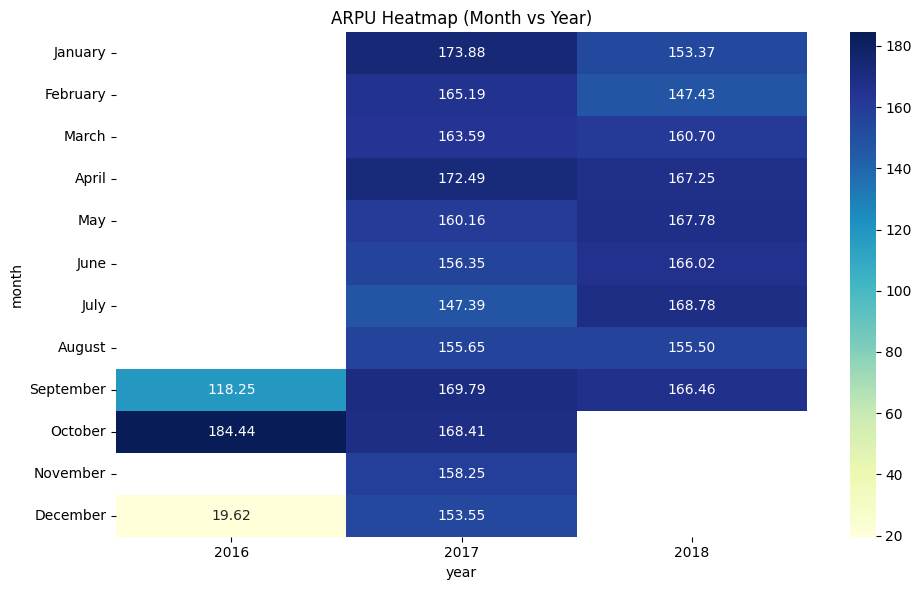

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

monthly_arpu['year'] = monthly_arpu['year_month'].dt.year
monthly_arpu['month'] = monthly_arpu['year_month'].dt.month_name()

pivot = monthly_arpu.pivot(index='month', columns='year', values='ARPU')
pivot = pivot.reindex([
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'])

plt.figure(figsize=(10,6))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("ARPU Heatmap (Month vs Year)")
plt.tight_layout()
plt.show()


In [ ]:
duckdb.register("products", df_dict['olist_products_dataset'])
duckdb.register("trans", df_dict['product_category_name_translation'])
duckdb.register("customers", df_dict['olist_customers_dataset'])


query = """
    SELECT 
        t.product_category_name_english AS category,
        c.customer_state AS state,
        strftime(o.order_purchase_timestamp, '%Y-%m') AS order_month,
        SUM(i.price + i.freight_value) AS total_revenue
    FROM items i
    LEFT JOIN products p ON i.product_id = p.product_id
    LEFT JOIN trans t ON p.product_category_name = t.product_category_name
    LEFT JOIN orders o ON i.order_id = o.order_id
    LEFT JOIN customers c ON o.customer_id = c.customer_id
    GROUP BY category, state, order_month
    ORDER BY total_revenue DESC
"""
rev_breakdown = duckdb.query(query).to_df()

In [ ]:
# Convert to datetime format
rev_breakdown['order_month'] = pd.to_datetime(rev_breakdown['order_month'])

# Format as "Month Year" for plotting
rev_breakdown['month_year'] = rev_breakdown['order_month'].dt.strftime('%b %Y')


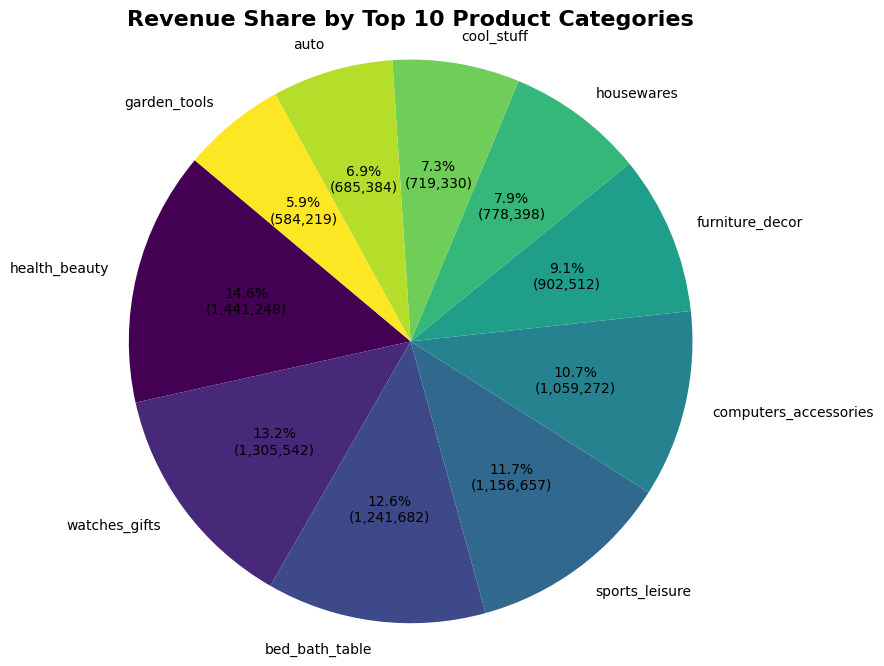

In [ ]:
# Enable inline plotting in Jupyter
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np

# Top 10 product categories by revenue
category_rev = (
    rev_breakdown.groupby('category')['total_revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

# Add percent share for labels
category_rev['percent'] = (
    category_rev['total_revenue'] / category_rev['total_revenue'].sum()
) * 100

# --- Plot with Matplotlib ---
plt.figure(figsize=(8, 8))

# Create pie chart with percent + absolute revenue labels
plt.pie(
    category_rev['total_revenue'],
    labels=category_rev['category'],
    autopct=lambda pct: f"{pct:.1f}%\n({pct/100*category_rev['total_revenue'].sum():,.0f})",
    startangle=140,
    colors=plt.cm.viridis(np.linspace(0, 1, len(category_rev)))
)

# Add title
plt.title('Revenue Share by Top 10 Product Categories', fontsize=16, fontweight='bold')

# Equal aspect ratio ensures pie is drawn as a circle
plt.axis('equal')

# Show chart inline
plt.show()

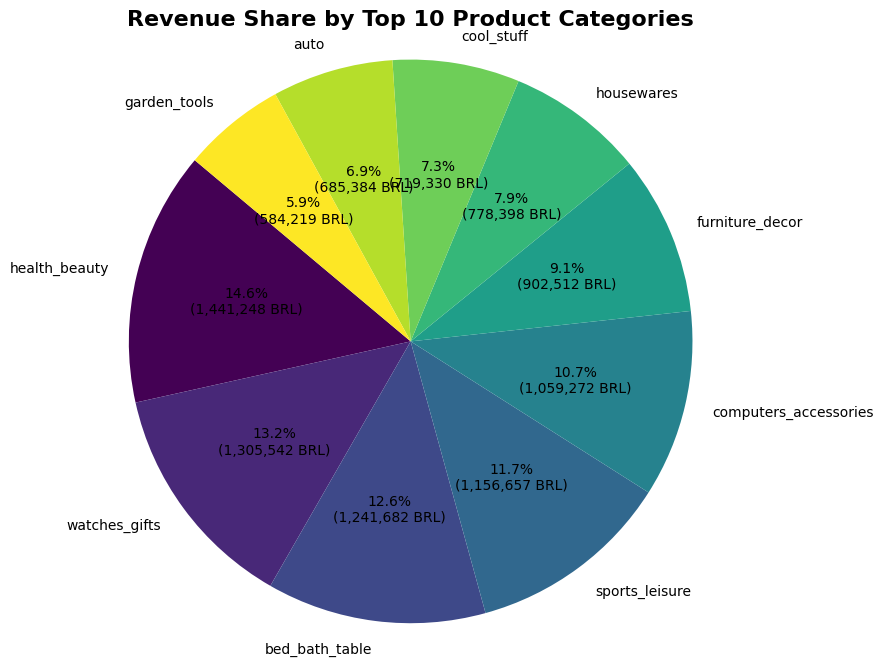

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Top 10 product categories by revenue
category_rev = (
    rev_breakdown.groupby('category')['total_revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

# Add percent share for labels
category_rev['percent'] = (
    category_rev['total_revenue'] / category_rev['total_revenue'].sum()
) * 100

# --- Plot with Matplotlib ---
plt.figure(figsize=(8, 8))

# Create pie chart
plt.pie(
    category_rev['total_revenue'],
    labels=category_rev['category'],
    autopct=lambda pct: f"{pct:.1f}%\n({pct/100*category_rev['total_revenue'].sum():,.0f} BRL)", 
    startangle=140,
    colors=plt.cm.viridis(np.linspace(0, 1, len(category_rev)))
)

# Add title
plt.title('Revenue Share by Top 10 Product Categories', fontsize=16, fontweight='bold')

# Equal aspect ratio ensures pie is drawn as a circle
plt.axis('equal')

# Show chart inline
plt.show()

In [ ]:
customers = df_dict['olist_customers_dataset']  # Access in Python
customers['customer_state'] = customers['customer_state'].str.strip().str.upper()

duckdb.register("customers", customers) 


sales_by_state = duckdb.query("""
    SELECT 
        c.customer_state AS state,
        SUM(i.price) AS total_sales
    FROM orders o
    JOIN customers c ON o.customer_id = c.customer_id
    JOIN items i ON o.order_id = i.order_id
    GROUP BY c.customer_state
""").to_df()

In [ ]:
import json, urllib.request, plotly.express as px
import pandas as pd
from IPython.display import HTML

# --- Load Brazil GeoJSON ---
url = "https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson"
with urllib.request.urlopen(url) as response:
    brazil_geo = json.load(response)

# --- Example sales_by_state DataFrame (replace with your own data) ---
sales_by_state = pd.DataFrame({
    "state": ["SP","RJ","MG","BA","RS"],
    "total_sales": [100000, 85000, 90000, 70000, 65000]
})

# --- Ensure state codes are strings ---
sales_by_state['state'] = sales_by_state['state'].astype(str)

# --- Build choropleth map ---
fig = px.choropleth_mapbox(
    sales_by_state,
    geojson=brazil_geo,
    locations="state",
    featureidkey="properties.sigla",
    color="total_sales",
    color_continuous_scale="YlGnBu",
    mapbox_style="carto-positron",
    center={"lat": -14.2350, "lon": -51.9253},
    zoom=3.5,
    opacity=0.7,
    title="Total Sales by Brazilian State"
)

fig.update_layout(margin={"r":0,"t":30,"l":0,"b":0}, height=600, width=800)

# --- Embed interactive map directly in notebook ---
html_str = fig.to_html(include_plotlyjs='cdn')
HTML(html_str)

In [ ]:

order_items = df_dict['olist_order_items_dataset']

# Total Units Sold
total_units_sold = order_items['order_item_id'].count()
print("Total Units Sold:", total_units_sold)


Total Units Sold: 112650


In [ ]:
order_items = df_dict['olist_order_items_dataset']

# Total Units Sold
total_units_sold = order_items['order_item_id'].count()
print("Total Units Sold:", total_units_sold)

# Build your Plotly figure (example: horizontal bar chart)
import plotly.express as px
from IPython.display import HTML

# Example: just a simple bar chart for testing
fig = px.bar(
    x=["SP","RJ","MG"],
    y=[1000, 850, 900],
    labels={'x':'State','y':'Units Sold'},
    title='Test Chart'
)

# Convert to HTML and display inline
html_str = fig.to_html(include_plotlyjs='cdn')
HTML(html_str)   # <-- must be the last line in the cell

Total Units Sold: 112650


In [ ]:
import duckdb
import plotly.express as px
import pandas as pd
from IPython.display import HTML

# Step 1: Register necessary DataFrames
duckdb.register('order_items', df_dict['olist_order_items_dataset'])
duckdb.register('sellers', df_dict['olist_sellers_dataset'])

# Step 2: DuckDB SQL query to get total revenue per seller
query = """
SELECT 
    o.seller_id,
    s.seller_city,
    s.seller_state,
    SUM(o.price + o.freight_value) AS total_revenue
FROM order_items o
JOIN sellers s ON o.seller_id = s.seller_id
GROUP BY o.seller_id, s.seller_city, s.seller_state
ORDER BY total_revenue DESC
LIMIT 10
"""
seller_revenue = duckdb.sql(query).df()

# Step 3: Create a readable label for y-axis
seller_revenue['seller_location'] = (
    seller_revenue['seller_city'] + " (" +
    seller_revenue['seller_state'] + ") - " +
    seller_revenue['seller_id'].str[:5]  # First 5 characters of ID
)

# Step 4: Interactive horizontal bar chart with Plotly
fig = px.bar(
    seller_revenue,
    x='total_revenue',
    y='seller_location',
    orientation='h',
    text='total_revenue',
    title='Top 10 Sellers by Total Revenue (Interactive)',
    labels={'total_revenue': 'Revenue (BRL)', 'seller_location': 'Seller Location'},
    color='total_revenue',
    color_continuous_scale='viridis'
)

fig.update_traces(
    hovertemplate='Seller: %{y}<br>Revenue: %{x:,.2f} BRL',  # formatted with commas
    texttemplate='%{x:,.2f}',
    textposition='outside'
)

fig.update_layout(
    height=600,
    xaxis_title='Revenue (BRL)',
    yaxis_title='Seller Location',
    yaxis={'categoryorder': 'total ascending'},
    template='plotly_white'
)

# --- Embed chart inline without fig.show() ---
html_str = fig.to_html(include_plotlyjs='cdn')
HTML(html_str)

In [ ]:
import duckdb
import pandas as pd
import plotly.express as px
from IPython.display import HTML

# Register DataFrames
duckdb.register('order_items', df_dict['olist_order_items_dataset'])
duckdb.register('orders', df_dict['olist_orders_dataset'])

# DuckDB query with proper formatting
query = """
SELECT 
    STRFTIME(order_purchase_timestamp, '%Y-%m') AS year_month,
    COUNT(*) AS total_units_sold
FROM order_items
JOIN orders ON order_items.order_id = orders.order_id
GROUP BY year_month
ORDER BY year_month
"""
units_by_month = duckdb.sql(query).df()

# Plotly Line Chart with category x-axis
fig = px.line(
    units_by_month,
    x='year_month',
    y='total_units_sold',
    title='Monthly Units Sold (OLIST)',
    labels={'year_month': 'Year-Month', 'total_units_sold': 'Units Sold'},
    markers=True
)

# Fix hover/x-axis issue
fig.update_layout(
    xaxis_type='category',
    xaxis_tickangle=-45,
    height=500,
    template='plotly_white'
)

# --- Embed chart inline without fig.show() ---
html_str = fig.to_html(include_plotlyjs='cdn')
HTML(html_str)

In [ ]:
import duckdb
import plotly.express as px
from IPython.display import HTML

# Register required DataFrames
duckdb.register('order_items', df_dict['olist_order_items_dataset'])
duckdb.register('orders', df_dict['olist_orders_dataset'])
duckdb.register('payments', df_dict['olist_order_payments_dataset'])

# Query to get revenue per payment type
query = """
SELECT 
    p.payment_type,
    SUM(oi.price + oi.freight_value) AS total_revenue
FROM order_items oi
JOIN orders o ON oi.order_id = o.order_id
JOIN payments p ON o.order_id = p.order_id
GROUP BY p.payment_type
ORDER BY total_revenue DESC
"""
payment_revenue = duckdb.sql(query).df()

# Create donut chart
fig = px.pie(
    payment_revenue,
    names='payment_type',
    values='total_revenue',
    title='Revenue by Payment Type',
    hole=0.4,
    color_discrete_sequence=px.colors.qualitative.Set2
)

fig.update_traces(
    textinfo='percent+label',
    hovertemplate='Payment Type: %{label}<br>Revenue: %{value:,.2f} BRL<extra></extra>'
)

fig.update_layout(
    height=500,
    showlegend=True,
    template='plotly_white'
)

# --- Embed chart inline without fig.show() ---
html_str = fig.to_html(include_plotlyjs='cdn')
HTML(html_str)

---------------------------------------**Customer Metrics**---------------------------------------------------------


In [ ]:
import duckdb
import pandas as pd
import plotly.express as px
from IPython.display import HTML
import numpy as np

# Register DataFrames
duckdb.register('orders', df_dict['olist_orders_dataset'])
duckdb.register('order_items', df_dict['olist_order_items_dataset'])
duckdb.register('customers', df_dict['olist_customers_dataset'])

# Repeat vs One-Time Buyers
repeat_df = duckdb.sql("""
    SELECT c.customer_unique_id, COUNT(o.order_id) AS num_orders
    FROM orders o
    JOIN customers c ON o.customer_id = c.customer_id
    GROUP BY c.customer_unique_id
""").df()

repeat_df['customer_type'] = repeat_df['num_orders'].apply(
    lambda x: 'Repeat Buyer' if x > 1 else 'One-Time Buyer'
)
repeat_summary = repeat_df['customer_type'].value_counts().reset_index()
repeat_summary.columns = ['customer_type', 'count']

# Order frequency distribution
order_freq_dist = repeat_df['num_orders'].value_counts().sort_index().reset_index()
order_freq_dist.columns = ['num_orders', 'customer_count']

# CLV calculation
clv_df = duckdb.sql("""
    SELECT 
        c.customer_unique_id,
        SUM(oi.price + oi.freight_value) AS total_revenue
    FROM order_items oi
    JOIN orders o ON oi.order_id = o.order_id
    JOIN customers c ON o.customer_id = c.customer_id
    GROUP BY c.customer_unique_id
""").df()

clv_merged = clv_df.merge(repeat_df[['customer_unique_id', 'num_orders']], on='customer_unique_id')
clv_merged['estimated_clv'] = clv_merged['total_revenue']

# --- Chart 1: Repeat vs One-Time Buyers ---
fig1 = px.pie(
    repeat_summary,
    names='customer_type',
    values='count',
    title='Repeat vs One-Time Buyers',
    hole=0.4,
    color_discrete_sequence=px.colors.qualitative.Pastel
)
fig1.update_traces(textinfo='percent+label', pull=[0.02, 0.02])

# --- Chart 2: Customer Order Frequency Distribution ---
fig2 = px.line(
    order_freq_dist,
    x='num_orders',
    y='customer_count',
    title='Customer Order Frequency Distribution',
    markers=True,
    labels={'num_orders': 'Number of Orders', 'customer_count': 'Number of Customers'},
    color_discrete_sequence=['#00CC96']
)
fig2.update_layout(xaxis=dict(dtick=1), template='plotly_dark')

# --- Embed both charts inline ---
html_str1 = fig1.to_html(include_plotlyjs='cdn')
html_str2 = fig2.to_html(include_plotlyjs='cdn')

display(HTML(html_str1))
display(HTML(html_str2))

In [28]:
fig5 = px.scatter(
    clv_merged,
    x='num_orders',
    y='estimated_clv',
    title='CLV vs. Number of Orders',
    labels={'num_orders': 'Number of Orders', 'estimated_clv': 'Estimated CLV (BRL)'},
    color='estimated_clv',
    color_continuous_scale='Turbo'
)

fig5.update_layout(template='plotly_white')
fig5.show()


NameError: name 'px' is not defined

In [ ]:
from IPython.display import HTML
import plotly.express as px

# Scatter plot: CLV vs Number of Orders
fig5 = px.scatter(
    clv_merged,
    x='num_orders',
    y='estimated_clv',
    title='CLV vs. Number of Orders',
    labels={'num_orders': 'Number of Orders', 'estimated_clv': 'Estimated CLV (BRL)'},
    color='estimated_clv',
    color_continuous_scale='Turbo'
)

fig5.update_layout(template='plotly_white')

# Convert to HTML and display inline
html_str = fig5.to_html(include_plotlyjs='cdn')
HTML(html_str)

In [ ]:
!pip install textblob

In [29]:
import pandas as pd
import plotly.express as px
from textblob import TextBlob
from IPython.display import HTML, display

# Load reviews
reviews = df_dict['olist_order_reviews_dataset']

# --- Rating distribution ---
rating_summary = reviews['review_score'].value_counts().sort_index().reset_index()
rating_summary.columns = ['review_score', 'count']
avg_rating = reviews['review_score'].mean().round(2)

fig1 = px.bar(
    rating_summary,
    x='review_score',
    y='count',
    title=f'Customer Review Score Distribution (Avg Rating: {avg_rating})',
    labels={'review_score': 'Review Score', 'count': 'Number of Reviews'},
    color='review_score',
    color_continuous_scale='Sunset'
)

# --- Sentiment analysis ---
text_df = reviews[['review_id', 'review_comment_message']].dropna()
text_df = text_df[text_df['review_comment_message'].str.strip() != '']
text_df['polarity'] = text_df['review_comment_message'].apply(lambda x: TextBlob(x).sentiment.polarity)

def classify_sentiment(score):
    if score > 0.1:
        return 'Positive'
    elif score < -0.1:
        return 'Negative'
    else:
        return 'Neutral'

text_df['sentiment'] = text_df['polarity'].apply(classify_sentiment)
sentiment_summary = text_df['sentiment'].value_counts().reset_index()
sentiment_summary.columns = ['sentiment', 'count']

fig2 = px.pie(
    sentiment_summary,
    names='sentiment',
    values='count',
    title='Sentiment Breakdown of Customer Reviews',
    color_discrete_sequence=px.colors.qualitative.Prism
)

# --- Embed both charts inline ---
html_str1 = fig1.to_html(include_plotlyjs='cdn')
html_str2 = fig2.to_html(include_plotlyjs='cdn')

display(HTML(html_str1))
display(HTML(html_str2))

In [30]:
import pandas as pd
import plotly.express as px
from IPython.display import HTML

df = df_dict['olist_order_reviews_dataset']

# Convert to datetime and extract month
df['review_creation_date'] = pd.to_datetime(df['review_creation_date'])
df['month'] = df['review_creation_date'].dt.to_period('M').astype(str)

# Compute monthly average review score
monthly_avg = df.groupby('month')['review_score'].mean().reset_index()
monthly_avg['review_score'] = monthly_avg['review_score'].round(2)

# Build line chart
fig = px.line(
    monthly_avg,
    x='month',
    y='review_score',
    title='Average Review Score Over Time',
    labels={'month': 'Month', 'review_score': 'Avg Review Score'},
    markers=True
)

fig.update_layout(xaxis_tickangle=-45, height=500, template='plotly_white')

# --- Embed chart inline without fig.show() ---
html_str = fig.to_html(include_plotlyjs='cdn')
HTML(html_str)

---------------------------------**Shipping and Delivery Analysis**-------------------------------------------------


In [32]:
import pandas as pd
import plotly.express as px
from IPython.display import HTML, display

orders = df_dict['olist_orders_dataset']
customers = df_dict['olist_customers_dataset']

# Convert date columns
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
orders[date_cols] = orders[date_cols].apply(pd.to_datetime)

# --- Delivery time ---
orders['delivery_time'] = (orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']).dt.days
avg_delivery_time = orders['delivery_time'].mean().round(2)

fig1 = px.histogram(
    orders,
    x='delivery_time',
    nbins=30,
    title=f'Delivery Time Distribution (Avg: {avg_delivery_time} days)',
    labels={'delivery_time': 'Delivery Time (days)'},
    color_discrete_sequence=['#636EFA']
)

# --- Shipping time ---
orders['shipping_time'] = (orders['order_delivered_carrier_date'] - orders['order_approved_at']).dt.days
avg_shipping_time = orders['shipping_time'].mean().round(2)

fig2 = px.histogram(
    orders,
    x='shipping_time',
    nbins=30,
    title=f'Shipping Time Distribution (Approval to Carrier) (Avg: {avg_shipping_time} days)',
    labels={'shipping_time': 'Shipping Time (days)'},
    color_discrete_sequence=['#EF553B']
)

# --- Delay summary ---
orders['delay'] = (orders['order_delivered_customer_date'] > orders['order_estimated_delivery_date'])
delay_summary = orders['delay'].value_counts().reset_index()
delay_summary.columns = ['is_delayed', 'count']

fig3 = px.pie(
    delay_summary,
    names='is_delayed',
    values='count',
    title='Delivery: Delayed vs On-Time',
    color_discrete_sequence=px.colors.sequential.RdBu
)

# --- Delay by state ---
merged = orders.merge(customers[['customer_id', 'customer_state']], on='customer_id', how='left')
merged = merged[merged['order_delivered_customer_date'].notnull()]
merged['delay_days'] = (merged['order_delivered_customer_date'] - merged['order_estimated_delivery_date']).dt.days

state_delay = merged.groupby('customer_state')['delay_days'].mean().reset_index()
state_delay['delay_days'] = state_delay['delay_days'].round(2)

fig4 = px.bar(
    state_delay.sort_values('delay_days', ascending=False),
    x='delay_days',
    y='customer_state',
    orientation='h',
    title='Average Delivery Delay by State',
    labels={'delay_days': 'Avg Delay (days)', 'customer_state': 'State'},
    color='delay_days',
    color_continuous_scale='Blues'
)

# --- Embed all charts inline ---
for fig in [fig1, fig2, fig3, fig4]:
    html_str = fig.to_html(include_plotlyjs='cdn')
    display(HTML(html_str))

In [33]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from IPython.display import HTML, display

orders = df_dict['olist_orders_dataset']
orders_dates = orders[[
    'order_id',
    'order_status',
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date'
]].copy()

# Drop rows with missing timestamps
orders_dates = orders_dates.dropna()

# Convert to datetime
orders_dates['order_purchase_timestamp'] = pd.to_datetime(orders_dates['order_purchase_timestamp'])
orders_dates['order_approved_at'] = pd.to_datetime(orders_dates['order_approved_at'])
orders_dates['order_delivered_carrier_date'] = pd.to_datetime(orders_dates['order_delivered_carrier_date'])
orders_dates['order_delivered_customer_date'] = pd.to_datetime(orders_dates['order_delivered_customer_date'])

# Compute durations
orders_dates['purchase_to_approval'] = (orders_dates['order_approved_at'] - orders_dates['order_purchase_timestamp']).dt.days
orders_dates['approval_to_carrier'] = (orders_dates['order_delivered_carrier_date'] - orders_dates['order_approved_at']).dt.days
orders_dates['carrier_to_customer'] = (orders_dates['order_delivered_customer_date'] - orders_dates['order_delivered_carrier_date']).dt.days
orders_dates['total_time'] = (orders_dates['order_delivered_customer_date'] - orders_dates['order_purchase_timestamp']).dt.days

avg_times = orders_dates[['purchase_to_approval', 'approval_to_carrier', 'carrier_to_customer']].mean().round(2)

# --- Chart 1: Total delivery time distribution ---
fig1 = px.histogram(
    orders_dates,
    x='total_time',
    nbins=30,
    title='Total Time from Order to Delivery (Days)',
    color_discrete_sequence=['#00CC96'],
    labels={'total_time': 'Delivery Duration'}
)

# --- Chart 2: Delivered vs Cancelled orders ---
cancelled = orders[orders['order_status'] == 'canceled'].shape[0]
delivered = orders[orders['order_status'] == 'delivered'].shape[0]

fig2 = px.pie(
    names=['Delivered', 'Cancelled'],
    values=[delivered, cancelled],
    title='Delivered vs Cancelled Orders',
    color_discrete_sequence=['#636EFA', '#EF553B']
)

# --- Chart 3: Funnel of average times ---
fig3 = go.Figure(go.Funnel(
    y=['Purchase → Approval', 'Approval → Carrier', 'Carrier → Customer'],
    x=avg_times.values,
    textinfo="value+percent initial",
    marker={"color": ["#AB63FA", "#FFA15A", "#19D3F3"]}
))
fig3.update_layout(title='Average Time Taken at Each Stage (in Days)', height=500)

# --- Embed all charts inline ---
for fig in [fig1, fig2, fig3]:
    html_str = fig.to_html(include_plotlyjs='cdn')
    display(HTML(html_str))

In [35]:
import pandas as pd
import plotly.express as px
from IPython.display import HTML

orders = df_dict['olist_orders_dataset'].copy()

# Convert timestamps
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])

# Flag delayed orders
orders['is_delayed'] = orders['order_delivered_customer_date'] > orders['order_estimated_delivery_date']

# Extract month
orders['month'] = orders['order_purchase_timestamp'].dt.to_period('M').astype(str)

# Monthly delayed orders
monthly_delays = orders.groupby('month')['is_delayed'].sum().reset_index()
monthly_delays.columns = ['month', 'delayed_order_count']

# Build line chart
fig = px.line(
    monthly_delays,
    x='month',
    y='delayed_order_count',
    title='Monthly Count of Delayed Orders',
    labels={'month': 'Month', 'delayed_order_count': 'Delayed Orders'},
    markers=True
)

fig.update_layout(xaxis_tickangle=-45, height=500, template='plotly_white')

# --- Embed chart inline without fig.show() ---
html_str = fig.to_html(include_plotlyjs='cdn')
HTML(html_str)